In [3]:
# ==========================================
# CELL 1: DYNAMIC ELEVATION & ATMOSPHERIC PRESSURE (BULLETPROOF)
# ==========================================
import pandas as pd
import numpy as np
import rasterio
from pyproj import Transformer
import os

base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

# 1. Load Station Coordinates
obs_path = os.path.join(base_dir, "Observed_Rainfall_1981_2014.csv")
df_coords = pd.read_csv(obs_path, nrows=2, index_col=0) 

stations = df_coords.T
stations.columns = ['Lon', 'Lat'] 
stations = stations.astype(float)

# 2. Extract Precise Elevations from the NASA SRTM DEM
dem_path = os.path.join(base_dir, "srtm_30m_nyabarongo.tif")
elevations = []

print("Extracting precise 30m elevations from NASA SRTM DEM...")

with rasterio.open(dem_path) as src:
    dem_crs = src.crs
    print(f"Detected DEM Coordinate System: {dem_crs}")
    
    # THE FIX: Create a mathematical transformer from WGS84 (Degrees) to the DEM's exact CRS
    transformer = Transformer.from_crs("EPSG:4326", dem_crs, always_xy=True)
    
    for idx, row in stations.iterrows():
        # Translate the degrees into the DEM's native format
        x, y = transformer.transform(row['Lon'], row['Lat'])
        coord = [(x, y)]
        
        try:
            elev = next(src.sample(coord))[0]
            if elev < -1000: 
                elev = np.nan
            elevations.append(elev)
        except Exception as e:
            print(f"Error sampling {idx}: {e}")
            elevations.append(np.nan)

stations['Elevation_m'] = elevations

# 3. Calculate Dynamic Atmospheric Pressure (P) [kPa]
stations['Pressure_kPa'] = 101.3 * (((293 - 0.0065 * stations['Elevation_m']) / 293) ** 5.26)

print("\n--- Station Elevation & Pressure Summary ---")
display(stations.head())

Extracting precise 30m elevations from NASA SRTM DEM...
Detected DEM Coordinate System: COMPD_CS["WGS84 TM Rwanda + EGM96 height",PROJCS["WGS84 TM Rwanda",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",30],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",500000],PARAMETER["false_northing",5000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]],VERT_CS["EGM96 height",VERT_DATUM["EGM96 geoid",2005,AUTHORITY["EPSG","5171"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP],AUTHORITY["EPSG","5773"]]]

--- Station Elevation & Pressure Summary ---


,Lon,Lat,Elevation_m,Pressure_kPa
Muhanda/Rubaya,29.63,-1.95,1679,82.965335
Gitega,30.06,-1.96,1534,84.433830
Butamwa,30.03,-2.01,1557,84.199502
Kabuye SW,30.07,-1.89,1381,86.006099
KIGALIAERO,30.11,-1.95,1458,85.211890


In [4]:
# ==========================================
# CELL 2: EXTRACT & CONVERT CLIMATE VARIABLES FOR ET0
# ==========================================
import xarray as xr
import pandas as pd
import os

base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

def process_climate_var(var_name, scenario, start_year, end_year):
    """Loads NetCDF, flattens spatial grid, converts units, and extracts 12-month climatology."""
    filepath = os.path.join(base_dir, f"Nyabarongo_{var_name}_{scenario}_aggregated.nc")
    ds = xr.open_dataset(filepath)
    
    # Time slice strictly to our boundaries
    ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    # Spatial Aggregation (Average across the catchment)
    spatial_dims = [dim for dim in ds.dims if dim != 'time']
    if spatial_dims:
        ds = ds.mean(dim=spatial_dims)
        
    df = ds[var_name].to_dataframe().reset_index()
    
    # --- CRITICAL UNIT CONVERSIONS ---
    if var_name in ['tasmax', 'tasmin']:
        df['val'] = df[var_name] - 273.15  # Kelvin to Celsius
    elif var_name == 'rsds':
        df['val'] = df[var_name] * 0.0864  # W/m2 to MJ/m2/day
    elif var_name == 'sfcWind':
        df['val'] = df[var_name]           # m/s (Already correct for FAO-56)
        
    # Group by calendar month (1-12) to create the average climatological year
    monthly_avg = df.groupby(df['time'].dt.month)['val'].mean()
    return monthly_avg

print("Extracting and converting climate variables... Please wait.")

# We build a master DataFrame for the Historical Baseline first
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
et0_inputs_hist = pd.DataFrame({'Month': months})

# Execute the extraction and conversion for all four variables
et0_inputs_hist['Tmax_C'] = process_climate_var('tasmax', 'historical', 1981, 2014).values
et0_inputs_hist['Tmin_C'] = process_climate_var('tasmin', 'historical', 1981, 2014).values
et0_inputs_hist['Wind_ms'] = process_climate_var('sfcWind', 'historical', 1981, 2014).values
et0_inputs_hist['Rad_MJm2day'] = process_climate_var('rsds', 'historical', 1981, 2014).values

# Calculate the definitive average Catchment Elevation and Pressure from Cell 1
catchment_elev = stations['Elevation_m'].mean()
catchment_pressure = stations['Pressure_kPa'].mean()

print(f"\nSUCCESS! Catchment Mean Elevation: {catchment_elev:.1f} m")
print(f"Catchment Mean Pressure: {catchment_pressure:.2f} kPa")
print("\n--- Historical Climate Inputs for ET0 (1981-2014) ---")
display(et0_inputs_hist)

Extracting and converting climate variables... Please wait.

SUCCESS! Catchment Mean Elevation: 1891.2 m
Catchment Mean Pressure: 80.91 kPa

--- Historical Climate Inputs for ET0 (1981-2014) ---


,Month,Tmax_C,Tmin_C,Wind_ms,Rad_MJm2day
0,Jan,25.667027,13.664447,1.494912,18.221674
1,Feb,26.156380,14.007324,1.533231,18.608303
2,Mar,25.693438,14.056298,1.525811,18.603813
3,Apr,24.848980,14.145653,1.759369,19.024105
4,May,25.150797,13.983928,2.048476,19.006731
5,Jun,25.931881,13.163338,1.923289,17.819084
6,Jul,26.386559,12.957485,1.847817,17.239153
7,Aug,26.551205,13.597580,1.748863,17.693586
8,Sep,26.519617,13.805881,1.742356,19.877535
9,Oct,25.700041,13.828071,1.687752,20.072952


In [5]:
# ==========================================
# CELL 3: FAO-56 PENMAN-MONTEITH ET0 CALCULATION
# ==========================================
import numpy as np
import pandas as pd

# Constants for FAO-56
albedo = 0.23          # Default for green grass reference crop
sigma = 4.903e-9       # Stefan-Boltzmann constant [MJ/K4/m2/day]
G = 0                  # Soil heat flux (assumed negligible for monthly time steps)

# 1. Fetch the exact catchment latitude from our earlier stations data
catchment_lat = stations['Lat'].mean()
lat_rad = np.radians(catchment_lat)

# 2. Define Julian Days for the middle of each month (Jan-Dec)
julian_days = [15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345]

# Array to store our calculated ET0 values
et0_values = []

print("Executing Penman-Monteith thermodynamics...")

for index, row in et0_inputs_hist.iterrows():
    Tmax = row['Tmax_C']
    Tmin = row['Tmin_C']
    u2 = row['Wind_ms']
    Rs = row['Rad_MJm2day']
    J = julian_days[index]
    
    Tmean = (Tmax + Tmin) / 2.0
    
    # --- A. Psychrometric Constant & Vapor Pressure ---
    # Using the exact 80.91 kPa pressure calculated from the 30m DEM
    gamma = 0.000665 * catchment_pressure
    
    def e_sat(T): 
        return 0.6108 * np.exp((17.27 * T) / (T + 237.3))
    
    es = (e_sat(Tmax) + e_sat(Tmin)) / 2.0
    ea = e_sat(Tmin) # FAO recommended approximation when Relative Humidity is absent
    
    delta = (4098 * e_sat(Tmean)) / ((Tmean + 237.3)**2)
    
    # --- B. Radiation Physics ---
    Rns = (1 - albedo) * Rs
    
    # Extraterrestrial Radiation (Ra)
    dr = 1 + 0.033 * np.cos(2 * np.pi * J / 365)
    solar_dec = 0.409 * np.sin((2 * np.pi * J / 365) - 1.39)
    ws = np.arccos(-np.tan(lat_rad) * np.tan(solar_dec))
    
    Ra = (24 * 60 / np.pi) * 0.0820 * dr * (ws * np.sin(lat_rad) * np.sin(solar_dec) + 
                                            np.cos(lat_rad) * np.cos(solar_dec) * np.sin(ws))
    
    # Clear Sky Radiation (Rso) adjusted for 1,891m elevation
    Rso = (0.75 + (2e-5 * catchment_elev)) * Ra
    
    # Cloudiness factor
    Rs_Rso = Rs / Rso if Rso > 0 else 0
    Rs_Rso = min(max(Rs_Rso, 0.3), 1.0) 
    f = 1.35 * Rs_Rso - 0.35
    
    # Net Longwave Radiation (Rnl)
    Rnl = sigma * (((Tmax + 273.16)**4 + (Tmin + 273.16)**4) / 2) * (0.34 - 0.14 * np.sqrt(ea)) * f
    Rn = Rns - Rnl
    
    # --- C. Final ET0 Calculation ---
    et0 = (0.408 * delta * Rn + gamma * (900 / (Tmean + 273)) * u2 * (es - ea)) / (delta + gamma * (1 + 0.34 * u2))
    et0_values.append(et0)

# 3. Add ET0 to our dataset
et0_inputs_hist['ET0_mm_day'] = et0_values
et0_inputs_hist['ET0_mm_month'] = et0_inputs_hist['ET0_mm_day'] * [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

print("\nSUCCESS! Reference Evapotranspiration (ET0) Calculated.")
display(et0_inputs_hist[['Month', 'Tmax_C', 'Tmin_C', 'Rad_MJm2day', 'ET0_mm_day', 'ET0_mm_month']].round(2))

Executing Penman-Monteith thermodynamics...

SUCCESS! Reference Evapotranspiration (ET0) Calculated.


,Month,Tmax_C,Tmin_C,Rad_MJm2day,ET0_mm_day,ET0_mm_month
0,Jan,25.670000,13.66,18.219999,3.83,118.85
1,Feb,26.160000,14.01,18.610001,3.98,112.39
2,Mar,25.690001,14.06,18.600000,3.92,121.65
3,Apr,24.850000,14.15,19.020000,3.88,116.53
4,May,25.150000,13.98,19.010000,3.91,121.30
5,Jun,25.930000,13.16,17.820000,3.82,114.51
6,Jul,26.389999,12.96,17.240000,3.81,118.08
7,Aug,26.549999,13.60,17.690001,3.90,120.83
8,Sep,26.520000,13.81,19.879999,4.23,126.94
9,Oct,25.700001,13.83,20.070000,4.16,128.95


In [6]:
# ==========================================
# CELL 4: EFFECTIVE RAINFALL & CROP WATER REQUIREMENTS
# ==========================================
import pandas as pd
import numpy as np
import os

base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

# 1. Load Baseline Historical Rainfall for Peff Calculation
obs_path = os.path.join(base_dir, "Observed_Rainfall_1981_2014.csv")
df_obs_raw = pd.read_csv(obs_path, skiprows=[1, 2], low_memory=False)
df_obs_raw['Date'] = pd.to_datetime(df_obs_raw['ID'], format='%Y%m%d')

station_columns = df_obs_raw.columns.drop(['ID', 'Date'])
df_obs_raw[station_columns] = df_obs_raw[station_columns].astype(float)
df_obs_raw['Daily_Basin_Avg_mm'] = df_obs_raw[station_columns].mean(axis=1)

# Aggregate to monthly averages across the 34-year baseline
df_monthly = df_obs_raw[['Date', 'Daily_Basin_Avg_mm']].set_index('Date').resample('MS').sum().reset_index()
P_monthly = df_monthly.groupby(df_monthly['Date'].dt.month)['Daily_Basin_Avg_mm'].mean().values

# 2. Calculate Effective Rainfall (USDA SCS Method)
def usda_peff(p):
    if p < 250:
        return p * (125 - 0.2 * p) / 125
    else:
        return 125 + 0.1 * p

Peff_monthly = np.array([usda_peff(p) for p in P_monthly])

# 3. Define Crop Coefficients (Kc) for Rwandan Seasons (A & B)
# Season A (Sep-Jan) and Season B (Feb-Jun). Cassava is year-round.
kc_maize =   [0.35, 0.80, 1.15, 0.60, 0.00, 0.00, 0.00, 0.00, 0.35, 0.80, 1.15, 0.60] # Jan to Dec
kc_beans =   [0.35, 1.05, 0.30, 0.00, 0.00, 0.00, 0.00, 0.00, 0.35, 1.05, 0.30, 0.00]
kc_cassava = [0.80, 0.80, 1.10, 1.10, 1.10, 0.80, 0.60, 0.40, 0.40, 0.50, 0.60, 0.70] 

# 4. Compile the CROPWAT DataFrame
crop_df = pd.DataFrame({
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'Precip_mm': P_monthly,
    'Peff_mm': Peff_monthly,
    'ET0_mm': et0_inputs_hist['ET0_mm_month'].values
})

# Calculate ETc and NIWR for Maize
crop_df['Kc_Maize'] = kc_maize
crop_df['ETc_Maize'] = crop_df['ET0_mm'] * crop_df['Kc_Maize']
crop_df['NIWR_Maize'] = np.maximum(0, crop_df['ETc_Maize'] - crop_df['Peff_mm'])

# Calculate ETc and NIWR for Beans
crop_df['Kc_Beans'] = kc_beans
crop_df['ETc_Beans'] = crop_df['ET0_mm'] * crop_df['Kc_Beans']
crop_df['NIWR_Beans'] = np.maximum(0, crop_df['ETc_Beans'] - crop_df['Peff_mm'])

# Calculate ETc and NIWR for Cassava
crop_df['Kc_Cassava'] = kc_cassava
crop_df['ETc_Cassava'] = crop_df['ET0_mm'] * crop_df['Kc_Cassava']
crop_df['NIWR_Cassava'] = np.maximum(0, crop_df['ETc_Cassava'] - crop_df['Peff_mm'])

print("--- Baseline Agricultural Water Requirements (1981-2014) ---")
display(crop_df.round(1))

--- Baseline Agricultural Water Requirements (1981-2014) ---


,Month,Precip_mm,Peff_mm,ET0_mm,Kc_Maize,ETc_Maize,NIWR_Maize,Kc_Beans,ETc_Beans,NIWR_Beans,Kc_Cassava,ETc_Cassava,NIWR_Cassava
0,Jan,98.3,82.9,118.9,0.4,41.6,0.0,0.4,41.6,0.0,0.8,95.1,12.2
1,Feb,111.2,91.4,112.4,0.8,89.9,0.0,1.0,118.0,26.6,0.8,89.9,0.0
2,Mar,159.0,118.5,121.7,1.2,139.9,21.4,0.3,36.5,0.0,1.1,133.8,15.3
3,Apr,191.1,132.7,116.5,0.6,69.9,0.0,0.0,0.0,0.0,1.1,128.2,0.0
4,May,140.6,109.0,121.3,0.0,0.0,0.0,0.0,0.0,0.0,1.1,133.4,24.5
5,Jun,36.5,34.4,114.5,0.0,0.0,0.0,0.0,0.0,0.0,0.8,91.6,57.2
6,Jul,16.8,16.3,118.1,0.0,0.0,0.0,0.0,0.0,0.0,0.6,70.8,54.5
7,Aug,59.4,53.8,120.8,0.0,0.0,0.0,0.0,0.0,0.0,0.4,48.3,0.0
8,Sep,108.5,89.7,126.9,0.4,44.4,0.0,0.4,44.4,0.0,0.4,50.8,0.0
9,Oct,144.5,111.1,128.9,0.8,103.2,0.0,1.0,135.4,24.3,0.5,64.5,0.0


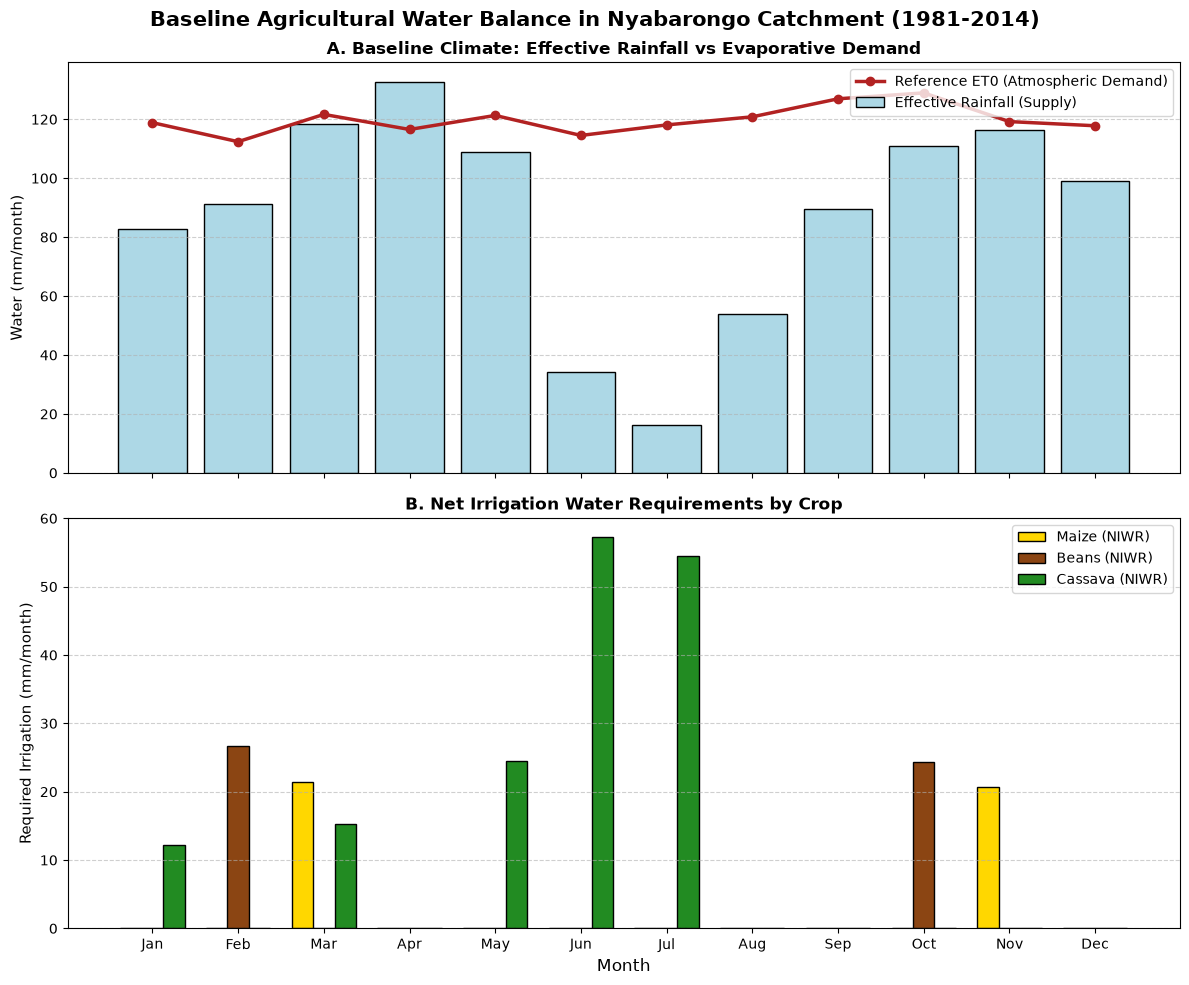

In [7]:
# ==========================================
# CELL 5: VISUALIZE BASELINE AGRICULTURAL DEFICITS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with 2 subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
x_indexes = np.arange(len(crop_df['Month']))
bar_width = 0.25

# --- PANEL A: Climate Supply vs General Demand ---
# We use Effective Rainfall as the true "Supply" and ET0 as the baseline "Demand"
ax1.bar(crop_df['Month'], crop_df['Peff_mm'], color='lightblue', edgecolor='black', label='Effective Rainfall (Supply)')
ax1.plot(crop_df['Month'], crop_df['ET0_mm'], color='firebrick', marker='o', linewidth=2.5, label='Reference ET0 (Atmospheric Demand)')

ax1.set_title('A. Baseline Climate: Effective Rainfall vs Evaporative Demand', fontsize=12, fontweight='bold')
ax1.set_ylabel('Water (mm/month)', fontsize=11)
ax1.legend(loc='upper right')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# --- PANEL B: Specific Crop Water Deficits (NIWR) ---
# Grouped bar chart to compare the irrigation needs of the three crops
ax2.bar(x_indexes - bar_width, crop_df['NIWR_Maize'], width=bar_width, color='gold', edgecolor='black', label='Maize (NIWR)')
ax2.bar(x_indexes, crop_df['NIWR_Beans'], width=bar_width, color='saddlebrown', edgecolor='black', label='Beans (NIWR)')
ax2.bar(x_indexes + bar_width, crop_df['NIWR_Cassava'], width=bar_width, color='forestgreen', edgecolor='black', label='Cassava (NIWR)')

ax2.set_title('B. Net Irrigation Water Requirements by Crop', fontsize=12, fontweight='bold')
ax2.set_ylabel('Required Irrigation (mm/month)', fontsize=11)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_xticks(x_indexes)
ax2.set_xticklabels(crop_df['Month'])
ax2.legend(loc='upper right')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Add a master title and adjust layout
plt.suptitle('Baseline Agricultural Water Balance in Nyabarongo Catchment (1981-2014)', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [9]:
# ==========================================
# CELL 6: FUTURE CLIMATE (2050) & CROPWAT PROJECTIONS (FIXED)
# ==========================================
import numpy as np
import pandas as pd
import xarray as xr
import os

print("Processing Future 2015-2050 Climate Models (SSP2-4.5 & SSP5-8.5)...")

base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

# --- THE BUG FIX: Upgraded function to handle Precipitation ('pr') ---
def process_climate_var(var_name, scenario, start_year, end_year):
    filepath = os.path.join(base_dir, f"Nyabarongo_{var_name}_{scenario}_aggregated.nc")
    ds = xr.open_dataset(filepath)
    ds = ds.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))
    
    spatial_dims = [dim for dim in ds.dims if dim != 'time']
    if spatial_dims:
        ds = ds.mean(dim=spatial_dims)
        
    df = ds[var_name].to_dataframe().reset_index()
    
    if var_name in ['tasmax', 'tasmin']:
        df['val'] = df[var_name] - 273.15
    elif var_name == 'rsds':
        df['val'] = df[var_name] * 0.0864
    elif var_name in ['sfcWind', 'pr']:  # Fix applied here
        df['val'] = df[var_name]
        
    return df.groupby(df['time'].dt.month)['val'].mean()

# Constants and definitions
days_in_month = np.array([31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
lat_rad = np.radians(stations['Lat'].mean())
julian_days = [15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345]

def run_future_cropwat(scenario_name):
    """End-to-End Pipeline: NetCDF -> ET0 -> NIWR for a given scenario"""
    
    # 1. Fetch Future Climate Variables
    Tmax = process_climate_var('tasmax', scenario_name, 2015, 2050).values
    Tmin = process_climate_var('tasmin', scenario_name, 2015, 2050).values
    u2 = process_climate_var('sfcWind', scenario_name, 2015, 2050).values
    Rs = process_climate_var('rsds', scenario_name, 2015, 2050).values
    
    # Rainfall (pr): Convert kg/m2/s to mm/day, then multiply by days to get monthly total
    pr_daily_avg = process_climate_var('pr', scenario_name, 2015, 2050).values
    P_monthly = pr_daily_avg * 86400 * days_in_month
    Peff_monthly = np.array([usda_peff(p) for p in P_monthly])
    
    # 2. Calculate Future ET0 (Penman-Monteith)
    et0_values = []
    gamma = 0.000665 * catchment_pressure
    
    for i in range(12):
        Tmean = (Tmax[i] + Tmin[i]) / 2.0
        es = (0.6108 * np.exp((17.27 * Tmax[i]) / (Tmax[i] + 237.3)) + 
              0.6108 * np.exp((17.27 * Tmin[i]) / (Tmin[i] + 237.3))) / 2.0
        ea = 0.6108 * np.exp((17.27 * Tmin[i]) / (Tmin[i] + 237.3))
        delta = (4098 * (0.6108 * np.exp((17.27 * Tmean) / (Tmean + 237.3)))) / ((Tmean + 237.3)**2)
        
        J = julian_days[i]
        dr = 1 + 0.033 * np.cos(2 * np.pi * J / 365)
        solar_dec = 0.409 * np.sin((2 * np.pi * J / 365) - 1.39)
        ws = np.arccos(-np.tan(lat_rad) * np.tan(solar_dec))
        Ra = (24 * 60 / np.pi) * 0.0820 * dr * (ws * np.sin(lat_rad) * np.sin(solar_dec) + 
                                                np.cos(lat_rad) * np.cos(solar_dec) * np.sin(ws))
        
        Rso = (0.75 + (2e-5 * catchment_elev)) * Ra
        Rs_Rso = min(max(Rs[i] / Rso if Rso > 0 else 0, 0.3), 1.0)
        f = 1.35 * Rs_Rso - 0.35
        
        Rns = (1 - 0.23) * Rs[i]
        Rnl = 4.903e-9 * (((Tmax[i] + 273.16)**4 + (Tmin[i] + 273.16)**4) / 2) * (0.34 - 0.14 * np.sqrt(ea)) * f
        Rn = Rns - Rnl
        
        et0 = (0.408 * delta * Rn + gamma * (900 / (Tmean + 273)) * u2[i] * (es - ea)) / (delta + gamma * (1 + 0.34 * u2[i]))
        et0_values.append(et0)
        
    ET0_monthly = np.array(et0_values) * days_in_month
    
    # 3. Calculate Future NIWR (Irrigation Deficit)
    niwr_maize = np.maximum(0, (ET0_monthly * np.array(kc_maize)) - Peff_monthly)
    niwr_beans = np.maximum(0, (ET0_monthly * np.array(kc_beans)) - Peff_monthly)
    niwr_cassava = np.maximum(0, (ET0_monthly * np.array(kc_cassava)) - Peff_monthly)
    
    return np.sum(niwr_maize), np.sum(niwr_beans), np.sum(niwr_cassava)

# Execute for both scenarios
maize_245, beans_245, cass_245 = run_future_cropwat('ssp245')
maize_585, beans_585, cass_585 = run_future_cropwat('ssp585')

# Calculate Baseline Annual Totals
base_maize = crop_df['NIWR_Maize'].sum()
base_beans = crop_df['NIWR_Beans'].sum()
base_cass = crop_df['NIWR_Cassava'].sum()

# Compile the Master Thesis Results Table
results_df = pd.DataFrame({
    'Crop Type': ['Maize (Season A/B)', 'Beans (Season A/B)', 'Cassava (Year-Round)'],
    'Historical Baseline (mm/year)': [base_maize, base_beans, base_cass],
    'SSP2-4.5 Projected (mm/year)': [maize_245, beans_245, cass_245],
    'SSP5-8.5 Projected (mm/year)': [maize_585, beans_585, cass_585]
})

# Calculate the critical "Difference" columns for Chapter 4 Discussion
results_df['Change under SSP2-4.5 (%)'] = ((results_df['SSP2-4.5 Projected (mm/year)'] - results_df['Historical Baseline (mm/year)']) / results_df['Historical Baseline (mm/year)'] * 100)
results_df['Change under SSP5-8.5 (%)'] = ((results_df['SSP5-8.5 Projected (mm/year)'] - results_df['Historical Baseline (mm/year)']) / results_df['Historical Baseline (mm/year)'] * 100)

print("\nSUCCESS! Master Future Projections Calculated.")
display(results_df.round(1))

Processing Future 2015-2050 Climate Models (SSP2-4.5 & SSP5-8.5)...

SUCCESS! Master Future Projections Calculated.


,Crop Type,Historical Baseline (mm/year),SSP2-4.5 Projected (mm/year),SSP5-8.5 Projected (mm/year),Change under SSP2-4.5 (%),Change under SSP5-8.5 (%)
0,Maize (Season A/B),42.1,69.5,68.4,65.1,62.4
1,Beans (Season A/B),50.9,92.3,82.4,81.2,61.9
2,Cassava (Year-Round),163.7,200.1,147.4,22.2,-10.0


In [10]:
# ==========================================
# THESIS IMAGE HARVESTER
# ==========================================
import os
import json
import base64

base_dir = r"C:\Users\Baikania Amonison\Desktop\final data extraction and analysis"

# Create a dedicated folder for the harvested images
output_dir = os.path.join(base_dir, "Thesis_Outputs", "Harvested_Images")
os.makedirs(output_dir, exist_ok=True)

# Find all Jupyter Notebooks in your directory
notebooks = [f for f in os.listdir(base_dir) if f.endswith('.ipynb')]

print(f"Found {len(notebooks)} notebooks. Beginning extraction...")

for nb_file in notebooks:
    print(f"\nScanning: {nb_file}...")
    nb_path = os.path.join(base_dir, nb_file)
    
    # Open and read the notebook's underlying JSON structure
    with open(nb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)
        
    image_count = 0
    # Search every single cell for hidden image data
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            for output in cell.get('outputs', []):
                if 'data' in output and 'image/png' in output['data']:
                    
                    # Extract and decode the base64 image string
                    img_data = output['data']['image/png']
                    image_count += 1
                    
                    # Create a clean, organized filename
                    clean_name = nb_file.replace('.ipynb', '')
                    img_name = f"{clean_name}_Figure_{image_count}.png"
                    img_path = os.path.join(output_dir, img_name)
                    
                    # Save it as a real PNG file
                    with open(img_path, "wb") as img_file:
                        img_file.write(base64.b64decode(img_data))
                        
    print(f"  -> Successfully extracted {image_count} images.")

print(f"\nSUCCESS! All visuals harvested and safely stored in:\n{output_dir}")

Found 4 notebooks. Beginning extraction...

Scanning: Climate_Extremes_Analysis.ipynb...
  -> Successfully extracted 3 images.

Scanning: Crop_Water_Requirements.ipynb...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)